# Information about Data set

## The Dataset being used for the project is from the Kaggle website: Credit Card Fraud Detection: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data

## The data is anonymized credit card transactions labeled as fraudulent or genuine. 

We will use this data train several models and then pick the model with the best performance.


In [1]:
# Importing all the needed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#sns.set_style("whitegrid")


## STEP 1: Import and understand the data


In [2]:
#Reading data into dataframes

data = pd.read_csv("creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Information on datatypes in data

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
#Statistics on Data

pd.set_option("display.float", "{:.2f}".format)
data.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


In [5]:
# Counting number of normal and fraud transaction entries

data['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

### Comments on Step 1

The data has 31 columns columns. The Class column is out Y variable the one we need to predict. The remaining columns are the features X. 
The datatype of 'class' is integer since it can only take 2 values. '0' for normal credit card transactions and '1' for fraudulant transactions. The remaining columns are all type float.
The data is skewed towards the normal transactions with 284315 normal transactions and only 492 are fradulant.

#   

## STEP2 : Clean the data

In [6]:
#Missing data

data.isnull().sum().sum()

0

In [7]:
#Duplicate data

data.duplicated().sum()

1081

In [8]:
#Removing Duplicates
duplicates = data[data.duplicated()]
data_cleaned = data.drop_duplicates()
print(f"Number of duplicate rows: {len(duplicates)}")
print(f"Number of rows after removing duplicates: {len(data_cleaned)}")
data=data_cleaned;

Number of duplicate rows: 1081
Number of rows after removing duplicates: 283726


In [9]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     28

In [10]:
# Checking if all duplicates are removed
data.duplicated().sum()

0

In [11]:
# Checking cleaned data
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,...,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00
mean,94811.08,0.01,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,...,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,88.47,0.00
std,47481.05,1.95,1.65,1.51,1.41,1.38,1.33,1.23,1.18,1.10,...,0.72,0.72,0.62,0.61,0.52,0.48,0.40,0.33,250.40,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54204.75,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.50,0.02,0.06,0.18,-0.02,-0.05,-0.28,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139298.00,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.51,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


In [12]:
data['Class'].value_counts()

0    283253
1       473
Name: Class, dtype: int64

### Comments on Step 2
There is no missing data in this dataset, however, there are certain duplicate entries. 
After removing the duplicates the number of normal class entries reduced to 283253 and the number of fraud transaction entries reduced to 473.

#  

## STEP 3: Exploratory Data Analysis

<Figure size 720x1440 with 0 Axes>

<Figure size 576x432 with 0 Axes>

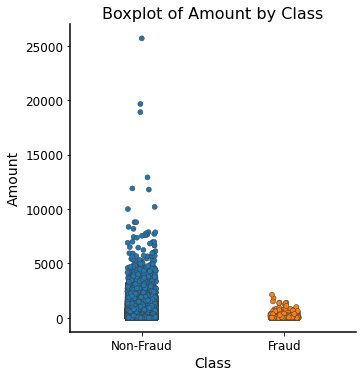

In [13]:
# Label the data as fraud and non-fraud data using the Class column
plt.figure(figsize=(10, 20))

LABELS = ["Non-Fraud", "Fraud"]

# Create plots to visualize the distribution between fraud and non-fraud cases
plt.figure(figsize=(8, 6))
sns.catplot(x='Class', y='Amount', data=data, linewidth=0.5)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Amount', fontsize=14)
plt.title('Boxplot of Amount by Class', fontsize=16)
plt.yticks(fontsize=12)
plt.xticks(range(2), LABELS, fontsize=12)

ax = plt.gca()  
for spine in ax.spines.values():
    spine.set_edgecolor('black')  
    spine.set_linewidth(1.5)  

# Display the plot
plt.show()


In [14]:
data.Class.value_counts()

0    283253
1       473
Name: Class, dtype: int64

In [15]:
fraud = data[data['Class']==1]
non_fraud = data[data['Class']==0]

print(f"Fraudulant transactions: {fraud.shape}")
print(f"Non-Fraudulant transactions: {non_fraud.shape}")

Fraudulant transactions: (473, 31)
Non-Fraudulant transactions: (283253, 31)


In [16]:
# Distribution of transaction amounts between fraud and non-fraud cases
pd.concat([fraud.Amount.describe(), non_fraud.Amount.describe()], axis=1, keys=["Fraud Amounts ($)", "Normal Amounts ($) "])


,Fraud Amounts ($),Normal Amounts ($)
count,473.00,283253.00
mean,123.87,88.41
std,260.21,250.38
min,0.00,0.00
25%,1.00,5.67
50%,9.82,22.00
75%,105.89,77.46
max,2125.87,25691.16


In [17]:
# Distribution of transaction times between fraud and non-fraud cases
pd.concat([fraud.Amount.describe(), non_fraud.Amount.describe()], axis=1, keys=["Fraud Time (sec) ", "Normal Time (sec) "])

,Fraud Time (sec),Normal Time (sec)
count,473.00,283253.00
mean,123.87,88.41
std,260.21,250.38
min,0.00,0.00
25%,1.00,5.67
50%,9.82,22.00
75%,105.89,77.46
max,2125.87,25691.16


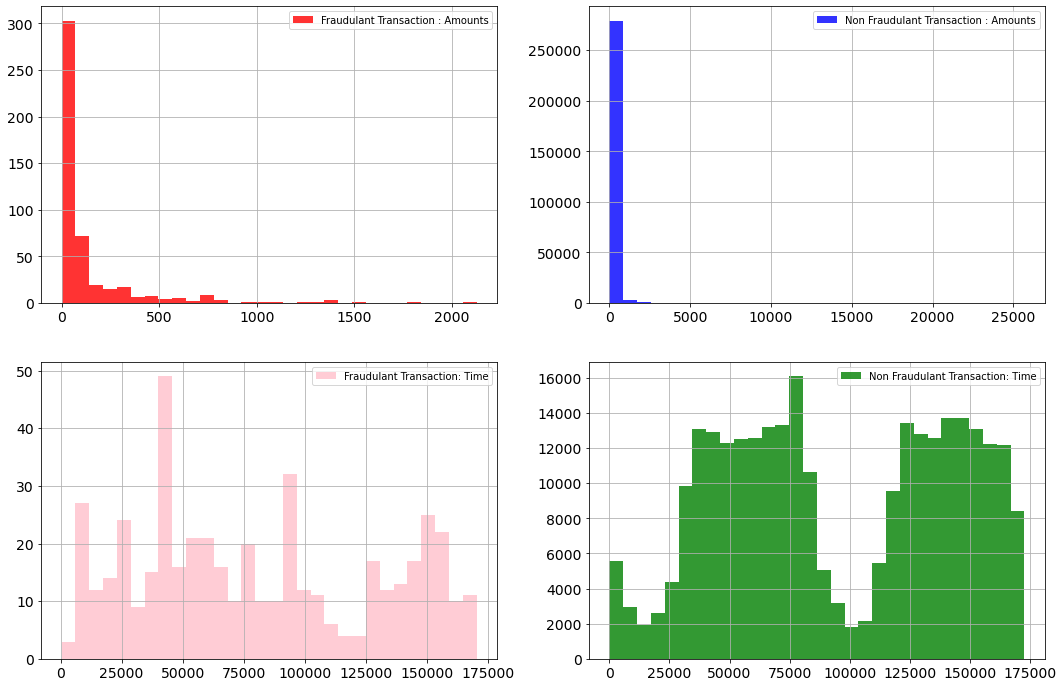

In [18]:
# Visualize the fraud and non-fraud data for transaction times and amounts

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
data[data.Class == 1].Amount.hist(bins=30, color='red', alpha=0.8, label="Fraudulant Transaction : Amounts")
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.legend()

plt.subplot(2, 2, 2)
data[data.Class == 0].Amount.hist(bins=30, color='blue', alpha=0.8, label="Non Fraudulant Transaction : Amounts")
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.legend()

plt.subplot(2, 2, 3)
data[data.Class == 1].Time.hist(bins=30, color='pink', alpha=0.8, label="Fraudulant Transaction: Time")
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.legend()

plt.subplot(2, 2, 4)
data[data.Class == 0].Time.hist(bins=30, color='green', alpha=0.8, label="Non Fraudulant Transaction: Time")
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.legend()


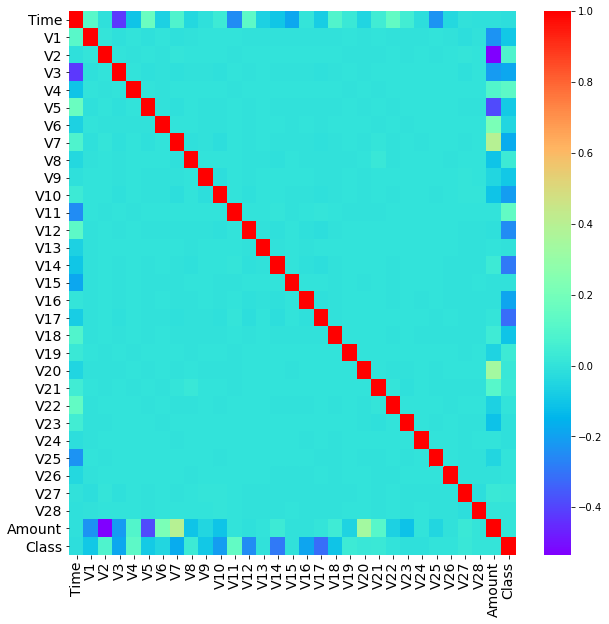

In [19]:
#Correlations in data with Heat map

plt.figure(figsize=(10,10))
sns.heatmap(data=data.corr(),cmap='rainbow')
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.show();


In [20]:
#Find the main features
abs(data.corr()['Class']).sort_values(ascending=False)

Class    1.00
V17      0.31
V14      0.29
V12      0.25
V10      0.21
V16      0.19
V3       0.18
V7       0.17
V11      0.15
V4       0.13
V18      0.11
V1       0.09
V9       0.09
V5       0.09
V2       0.08
V6       0.04
V19      0.03
V8       0.03
V21      0.03
V27      0.02
V20      0.02
Time     0.01
V28      0.01
V24      0.01
V23      0.01
Amount   0.01
V22      0.00
V26      0.00
V13      0.00
V15      0.00
V25      0.00
Name: Class, dtype: float64

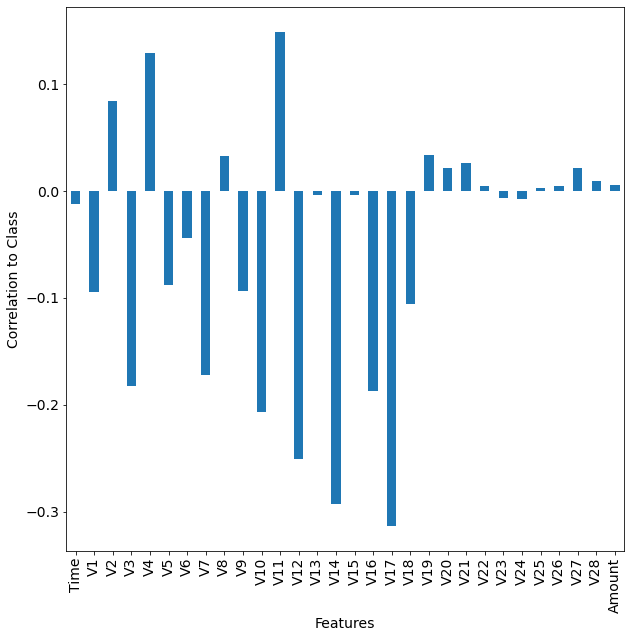

In [21]:
# Visualize the main features
plt.figure(figsize=(10,10))
m=data.corr().drop('Class')
m.Class.plot(kind = 'bar')

plt.xlabel('Features', fontsize=14)
plt.ylabel('Correlation to Class', fontsize=14)

# Set tick label font size

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

plt.show();

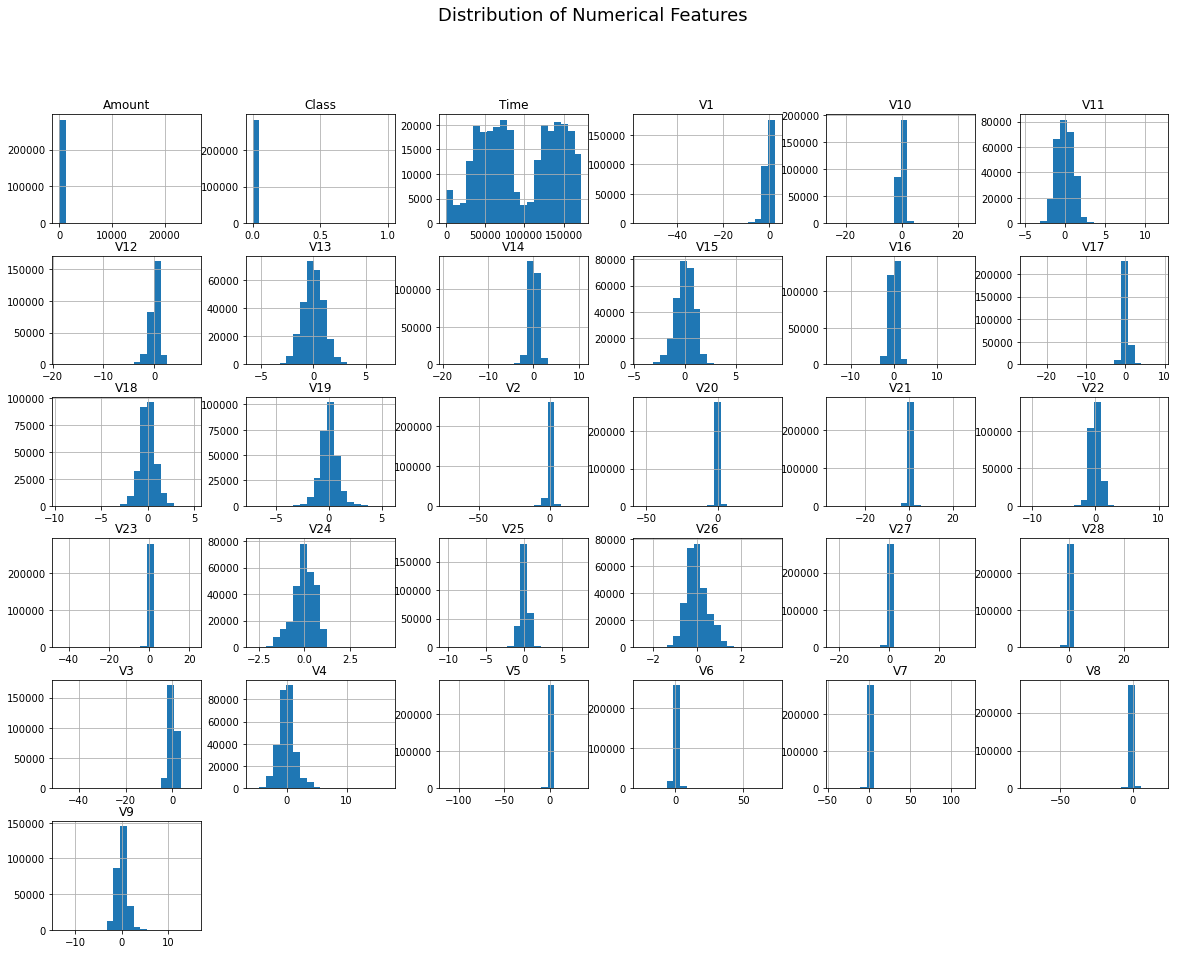

In [22]:
data.hist(figsize=(20, 15), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.show()

### Comments on Step 3
After doing EDA on the data the main insights of the data are as follows:
1. The number of non-fraud transactions are a lot more than the fraud transactions
2. The transaction amount in fraud transactions tends to be a lot smaller compared to the transaction amounts for normal transactions
3. The time required for fradulant transactions is also a lot smaller than normal transactions
4. After visualizing the corelations in the data with heat-maps we can see that all features have some correlation with the Class of transaction. However, V17, V14, V12, C10, V16, V3,V7, V11, V4 show the most correlations. These would be important features to use in the modelling of data. 

#  

## Step 4: Feature Selection/Engineering

In [23]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


# Identifying the features of importance

from sklearn.preprocessing import StandardScaler

# Scale the Amount column
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])


## Step 5: Data Splitting

In [24]:
from sklearn.model_selection import train_test_split

X = data.drop('Class', axis=1)  # Features
y = data['Class']  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Next the data is normalized with a scaler function.
Data is then divided into training data ans test data. 20% of data is reserved for testing

#  

## Step 6: Model Selection and Evaluations

Now that the data has been prepared, we can test out different models for prediction of fraudulant credit card transactions.
I will be training 6 different types of supervised learning models on the training data.
Next I will use the metrics and confusion matrix from each model to pick the best model for detection of fraudulant data.

The 6 models will be:
1. Linear Regression
2. Logistic Regression
3. Decision Tree
4. Random forests
5. Gradient Boost
6. K-Nearest Neighbors

In [25]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)  # K-Nearest Neighbors with k=5
}

# Evaluate each model and store results
results = {}
confusion_matrices = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the test data
    if name == "Linear Regression":  # Special case for Linear Regression
        y_pred = np.round(model.predict(X_test))  # Round predictions for classification
    else:
        y_pred = model.predict(X_test)
    
    # Store results
    results[name] = classification_report(y_test, y_pred, output_dict=True)
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    
    # Print evaluation metrics
    print(f"{name} Evaluation:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("\n")




Linear Regression Evaluation:
[[56651     5]
 [   54    36]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.88      0.40      0.55        90

    accuracy                           1.00     56746
   macro avg       0.94      0.70      0.77     56746
weighted avg       1.00      1.00      1.00     56746



Logistic Regression Evaluation:
[[56640    16]
 [   35    55]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.77      0.61      0.68        90

    accuracy                           1.00     56746
   macro avg       0.89      0.81      0.84     56746
weighted avg       1.00      1.00      1.00     56746



Decision Tree Evaluation:
[[56632    24]
 [   26    64]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.73      0.71      0.72        9

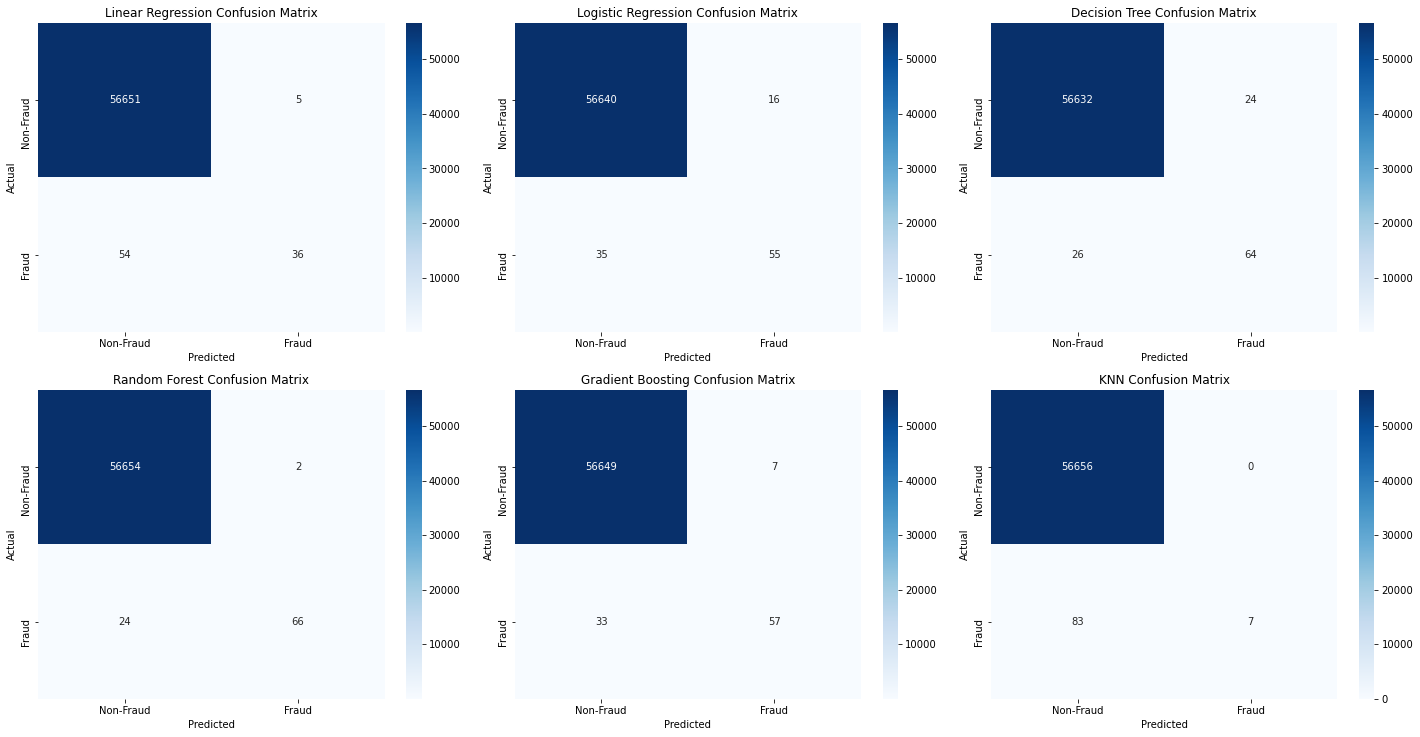

In [26]:
# Visualize Confusion Matrices
plt.figure(figsize=(20, 15))
for i, (name, cm) in enumerate(confusion_matrices.items()):
    plt.subplot(3, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Fraud", "Fraud"], yticklabels=["Non-Fraud", "Fraud"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Initialize a dictionary to store results
metrics_dict = {"Model": [], "Precision": [], "Recall": [], "F1-score": []}

# Iterate through each trained model and compute performance metrics
for name, model in models.items():
    if name == "Linear Regression":
        y_pred = np.round(model.predict(X_test))  # Round predictions for classification
    else:
        y_pred = model.predict(X_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)

    # Store precision, recall, and F1-score for the fraud class (Class = 1)
    metrics_dict["Model"].append(name)
    metrics_dict["Precision"].append(report["1"]["precision"])
    metrics_dict["Recall"].append(report["1"]["recall"])
    metrics_dict["F1-score"].append(report["1"]["f1-score"])

# Convert dictionary to DataFrame
metrics_df = pd.DataFrame(metrics_dict)



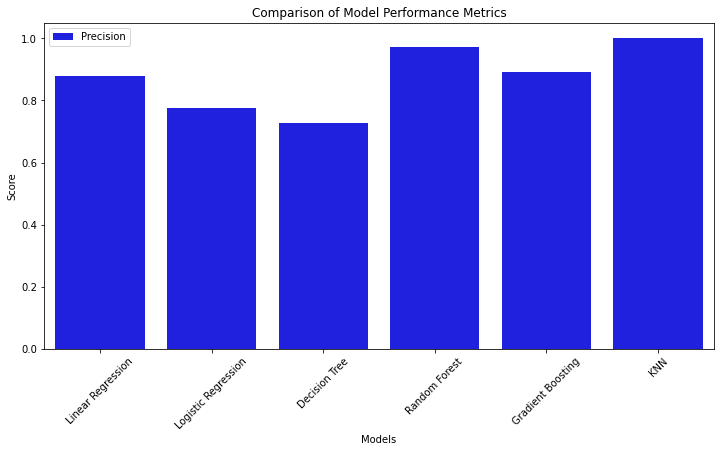

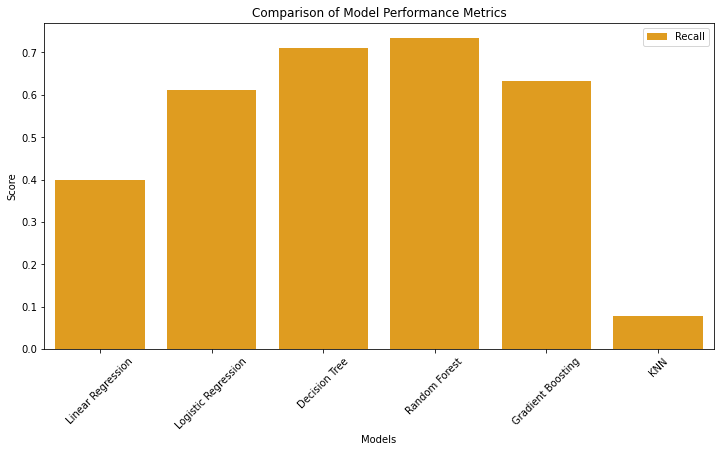

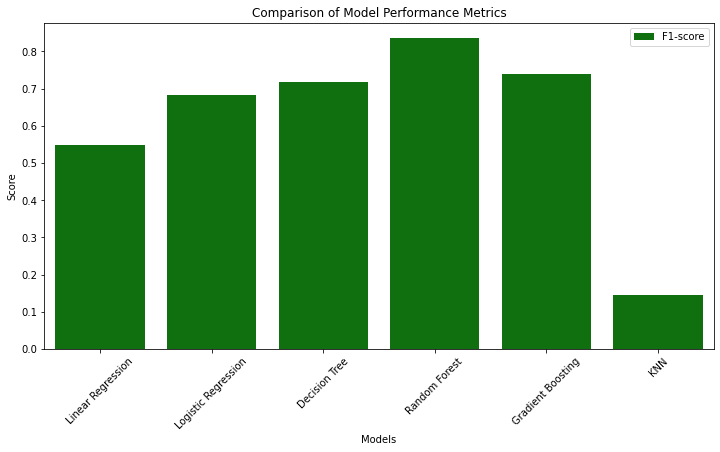

In [30]:
# Plot the metrics
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Precision", data=metrics_df, color='blue', label="Precision")


plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Comparison of Model Performance Metrics")
plt.legend()
plt.show()


plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Recall", data=metrics_df, color='orange', label="Recall")


plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Comparison of Model Performance Metrics")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="F1-score", data=metrics_df, color='green', label="F1-score")


plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Comparison of Model Performance Metrics")
plt.legend()
plt.show()




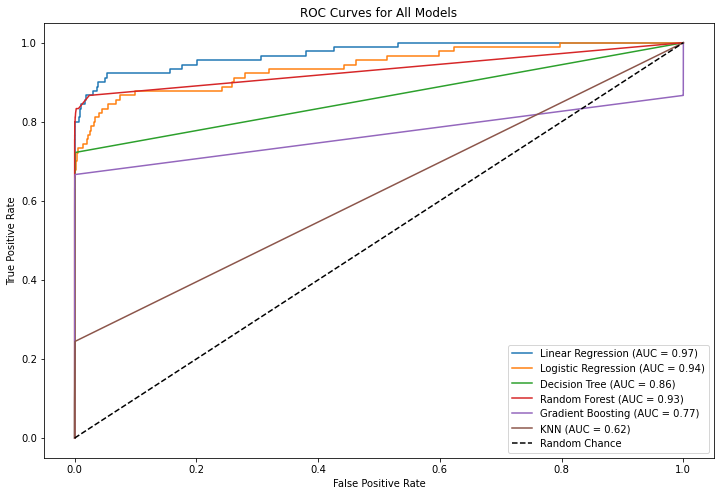

In [31]:
from sklearn.metrics import roc_curve, auc

# Plot ROC Curves
plt.figure(figsize=(12, 8))

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict probabilities (special case for Linear Regression)
    if name == "Linear Regression":
        y_prob = model.predict(X_test)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())  # Normalize to [0,1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]  # Get probabilities for class=1

    # Compute ROC curve and AUC score
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    
# Final plot adjustments
plt.plot([0, 1], [0, 1], 'k--', label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.show()

### Conclusions from model selection study:

Precision, Recall, F1 Score, ROC and AUC were calculated and looked at prediction accuracy for fraudulant transactions for the 6 models.

1. Linear Regression - Precison is 0.88, recall is 0.40 and F1 score is 0.55.
2. Logistic Regression - Precison is 0.77, recall is 0.61 and F1 score is 0.68.            
3. Decision Tree - Precison is 0.73, recall is  0.71 and F1 score is 0.72.  
4. Random forests - Precison is 0.97, recall is  0.73 and F1 score is 0.8.              
5. Gradient Boost - Precison is 0.89, recall is  0.63 and F1 score is 0.74. 
6. K-Nearest Neighbors - Precison is 1.00, recall is  0.08 and F1 score is 0.14. 

    Overall, the KNN model is the worst performing.

    Logistic regression and Liner Regression have intermediate performance.

    The Decision Tree and Gradient Boost have similar performance but better than Liner and Logistic regression.

    The Best performing model is 'Random Forest'.



## Step 7: Best model predictions and Insights

### The random forest model appears to be the best model for this fraud detection dataset. We can now tune the model by iterating on the hyperparameters

In [32]:
from sklearn.ensemble import RandomForestClassifier

X = data.drop("Class", axis=1)
y = data["Class"]

# Train a basic Random Forest model to analyze feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Display feature importance
import pandas as pd
importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)
print(importance)


   Feature  Importance
17     V17        0.15
14     V14        0.14
12     V12        0.12
10     V10        0.09
16     V16        0.07
11     V11        0.05
9       V9        0.04
18     V18        0.03
7       V7        0.03
4       V4        0.03
26     V26        0.02
3       V3        0.02
21     V21        0.02
20     V20        0.01
1       V1        0.01
6       V6        0.01
19     V19        0.01
27     V27        0.01
2       V2        0.01
15     V15        0.01
8       V8        0.01
0     Time        0.01
5       V5        0.01
29  Amount        0.01
28     V28        0.01
13     V13        0.01
24     V24        0.01
22     V22        0.01
23     V23        0.01
25     V25        0.01


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X, y)

best_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
best_rf.fit(X, y)